# Exploratory Data Analysis — Letterboxd Movie Ratings

This notebook performs an **Exploratory Data Analysis (EDA)** of a dataset containing publicly accessible movie ratings scraped from [Letterboxd](https://www.kaggle.com/datasets/samlearner/letterboxd-movie-ratings-data?select=movie_data.csv).

The dataset was collected from the **top 4,000 Letterboxd users** in a given month. Users' star ratings were scraped from their public profiles and converted into numerical ratings from **1 to 10**, accounting for half-star ratings. The movie information was additionally enriched using data retrieved from the **TMDB API**.

The data is provided in three tables, exported from a MongoDB database:

- **Users** — information about the users included in the dataset.
- **Movies** — information about the movies, enriched with TMDB data.
- **Ratings** — the ratings given by users to individual movies.

The main objective of this analysis is to understand the structure and characteristics of the dataset before developing a **movie rating prediction and recommendation system**. In particular, the analysis will focus on the distribution of ratings, user and movie activity, the sparsity of the user–movie interactions, and other properties that may influence the choice and design of the predictive model.

> **Dataset source:** [Letterboxd Movie Ratings Data — Kaggle](https://www.kaggle.com/datasets/samlearner/letterboxd-movie-ratings-data?select=movie_data.csv)

## Imports

In [6]:
import matplotlib.pyplot as plt
import os
import pandas as pd
from pathlib import Path

cwd = Path.cwd()

if "notebooks" in cwd.parts:
    project_root = cwd.parents[cwd.parts[::-1].index("notebooks")]
    os.chdir(project_root)

print("Current working directory:", os.getcwd())

Current working directory: c:\Users\Darío\Desktop\OTROS\vector-recommender


## Movie Data

We begin the exploratory analysis by examining the **movie data** table:

This table contains information about the movies included in the dataset, enriched with metadata obtained from the **TMDB API**.

The first step is to inspect its structure, dimensions, available variables, data types, and missing values. This will allow us to understand the movie-level information available and identify any data quality issues that may need to be addressed in subsequent stages of the analysis.

In [7]:
MOVIES_PATH = "data/raw/letterboxd_movie_ratings_dataset/movie_data.csv"

movies_df = pd.read_csv(
    MOVIES_PATH,
    engine="python",
)

movies_df.head()

,_id,genres,image_url,imdb_id,imdb_link,movie_id,movie_title,original_language,overview,popularity,production_countries,release_date,runtime,spoken_languages,tmdb_id,tmdb_link,vote_average,vote_count,year_released
0,5fc85f606758f69634496fd3,"[""Music"",""Animation""]",film-poster/4/6/4/4/4/0/464440-football-freaks...,NaN,NaN,football-freaks,Football Freaks,en,"Football crazy, football mad. Don’t watch this...",0.600,"[""United Kingdom""]",1971-12-05,0.0,[],535272.0,https://www.themoviedb.org/movie/535272/,0.0,0.0,1971.0
1,5fc85ff26758f696344ace0c,[],film-poster/2/4/5/5/0/0/245500-aftermath-0-230...,tt0586129,http://www.imdb.com/title/tt0586129/maindetails,aftermath-1960,Aftermath,en,Aftermath was the pilot for an unsold TV serie...,0.600,[],1960-04-17,22.0,[],318331.0,https://www.themoviedb.org/movie/318331/,8.0,1.0,1960.0
2,5fc85f606758f69634496fcd,"[""Drama""]",film-poster/9/3/3/1/8/93318-where-chimneys-are...,tt0045731,http://www.imdb.com/title/tt0045731/maindetails,where-chimneys-are-seen,Where Chimneys Are Seen,ja,Gosho’s most celebrated film both in Japan and...,1.568,"[""Japan""]",1953-03-05,108.0,"[""日本語""]",117779.0,https://www.themoviedb.org/movie/117779/,6.6,10.0,1953.0
3,5fc85f606758f69634496fd1,"[""Drama""]",NaN,tt0187327,http://www.imdb.com/title/tt0187327/maindetails,the-musicians-daughter,The Musician's Daughter,en,Carl Wagner's good wife was dying. His heart b...,0.600,"[""United States of America""]",1911-12-12,15.0,[],560377.0,https://www.themoviedb.org/movie/560377/,0.0,0.0,1911.0
4,5fc85f606758f69634496fd4,"[""Documentary""]",film-poster/4/5/4/6/0/3/454603-50-years-of-fab...,tt4769914,http://www.imdb.com/title/tt4769914/maindetails,50-years-of-fabulous,50 Years of Fabulous,en,50 Years of Fabulous recounts the rich history...,0.600,[],2018-05-17,75.0,[],525187.0,https://www.themoviedb.org/movie/525187/,0.0,0.0,2018.0


In [8]:
movies_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 285963 entries, 0 to 285962
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   _id                   285963 non-null  str    
 1   genres                274986 non-null  str    
 2   image_url             264521 non-null  str    
 3   imdb_id               243898 non-null  str    
 4   imdb_link             243914 non-null  str    
 5   movie_id              285616 non-null  str    
 6   movie_title           283453 non-null  str    
 7   original_language     274986 non-null  str    
 8   overview              261362 non-null  str    
 9   popularity            274872 non-null  float64
 10  production_countries  274854 non-null  str    
 11  release_date          270954 non-null  str    
 12  runtime               269943 non-null  float64
 13  spoken_languages      274758 non-null  str    
 14  tmdb_id               279803 non-null  float64
 15  tmdb_link  

### Missing values analysis

In [9]:
missing_values = pd.DataFrame({
    "missing_count": movies_df.isna().sum(),
    "missing_percentage": movies_df.isna().mean() * 100,
})

missing_values = (
    missing_values[missing_values["missing_count"] > 0]
    .sort_values("missing_count", ascending=False)
)

missing_values

,missing_count,missing_percentage
imdb_id,42065,14.709945
imdb_link,42049,14.704350
overview,24601,8.602861
image_url,21442,7.498173
runtime,16020,5.602123
release_date,15009,5.248581
vote_average,11205,3.918339
spoken_languages,11205,3.918339
vote_count,11205,3.918339
production_countries,11109,3.884768


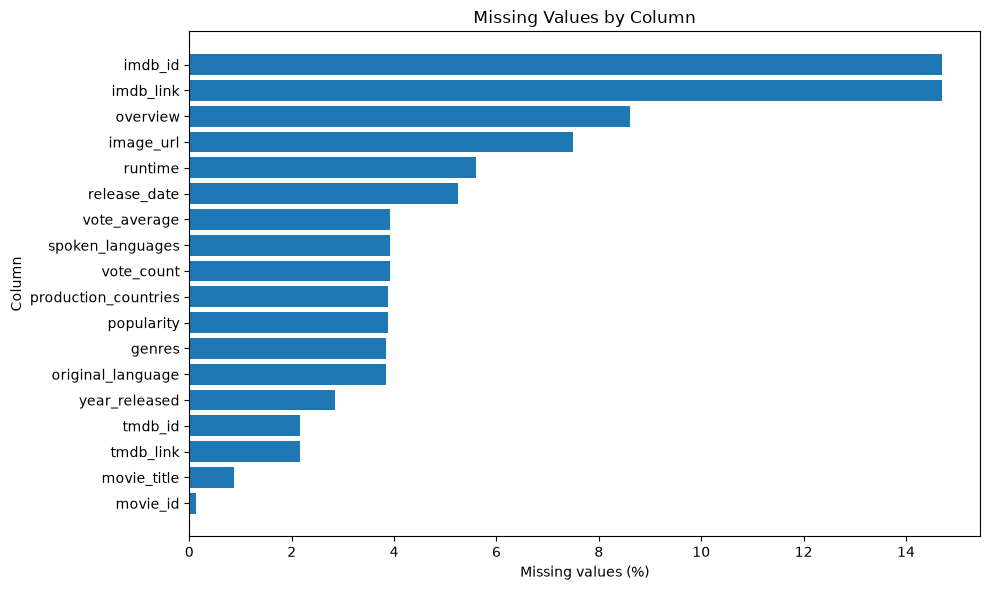

In [10]:
plt.figure(figsize=(10, 6))

plt.barh(
    missing_values.index[::-1],
    missing_values["missing_percentage"][::-1],
)

plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.title("Missing Values by Column")

plt.tight_layout()
plt.show()

## User Data

We now turn to the **user data** table.

This table contains information about the Letterboxd users included in the dataset. Understanding the available user-level attributes is important for assessing what information can potentially be used to characterize users and, ultimately, predict their movie preferences.

We first inspect the structure of the dataset, including its dimensions, columns, data types, and basic statistics. We will then examine the completeness of the available information and identify potential data quality issues.

In [11]:
USERS_PATH = "data/raw/letterboxd_movie_ratings_dataset/users_export.csv"

users_df = pd.read_csv(
    USERS_PATH,
    engine="python",
)

users_df.head()

,_id,display_name,num_ratings_pages,num_reviews,username
0,5fc4172ec6cd28ebd99dd0e2,Lucy,32.0,1650,deathproof
1,5fc4172ec6cd28ebd99dd0ea,Matt Singer,52.0,1915,superpulse
2,5fc4172ec6cd28ebd99dd0ed,Sean Baker,21.0,1283,lilfilm
3,5fc4172ec6cd28ebd99dd0ee,iana,37.0,1177,ianamurray
4,5fc419171ebf67b9fbe48615,Lizzy,57.0,1810,punchdrunklizzy


### `num_ratings_pages`

`num_ratings_pages` represents the **number of pages containing a user's movie ratings on Letterboxd** at the time of the last crawl.

This value was stored in the dataset to facilitate the web scraping process, allowing the crawler to know how many pages of ratings needed to be retrieved for each user without having to determine this again.

It should therefore not be interpreted as the number of ratings itself, but rather as an **indirect indicator of the amount of rating activity of a user**.

In [12]:
users_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8139 entries, 0 to 8138
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   _id                8139 non-null   str    
 1   display_name       7832 non-null   str    
 2   num_ratings_pages  4747 non-null   float64
 3   num_reviews        8139 non-null   int64  
 4   username           8139 non-null   str    
dtypes: float64(1), int64(1), str(3)
memory usage: 663.7 KB


In [13]:
missing_values = pd.DataFrame({
    "missing_count": users_df.isna().sum(),
    "missing_percentage": users_df.isna().mean() * 100,
})

missing_values = (
    missing_values[missing_values["missing_count"] > 0]
    .sort_values("missing_count", ascending=False)
)

missing_values.style.format({
    "missing_percentage": "{:.2f}%"
})

,missing_count,missing_percentage
num_ratings_pages,3392,41.68%
display_name,307,3.77%


Check for duplicate usernames

In [14]:
# Check for duplicated user IDs
users_df["username"].duplicated().sum()

np.int64(0)

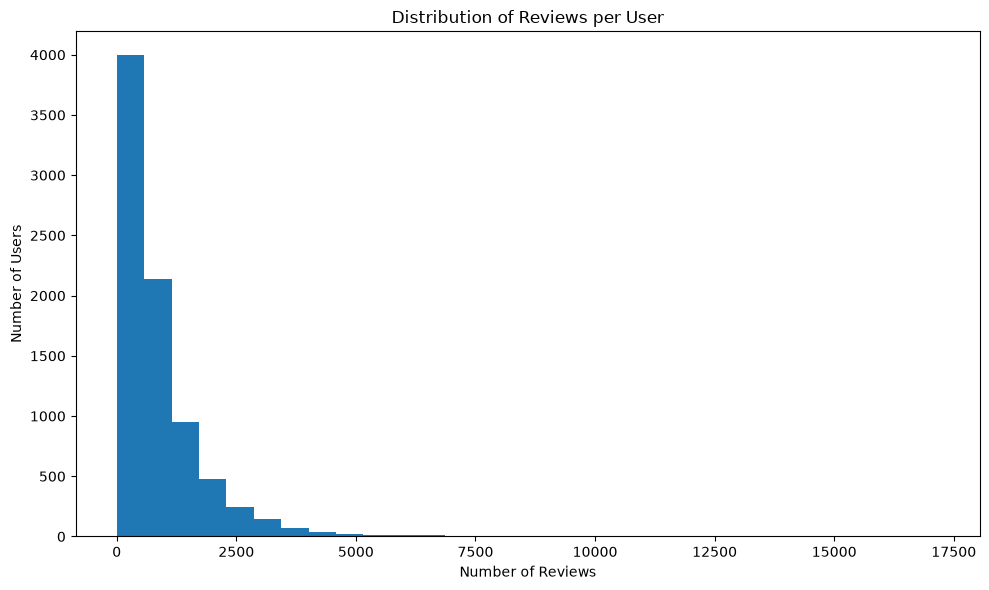

In [19]:
plt.figure(figsize=(10, 6))

plt.hist(
    users_df["num_reviews"].dropna(),
    bins=30,
)

plt.xlabel("Number of Reviews")
plt.ylabel("Number of Users")
plt.title("Distribution of Reviews per User")

plt.tight_layout()
plt.show()

## Ratings Data

We now turn to the **ratings data** table

This is the most important table for the movie rating prediction task, as it contains the **user–movie interactions** that describe which movies users have rated and the ratings they assigned to them.

Each record represents a rating given by a user to a movie. These interactions will ultimately form the basis for modeling user preferences and predicting how a user might rate movies they have not yet rated.

The first step is to inspect the structure and characteristics of the dataset, including its dimensions, columns, data types, rating distribution, and potential missing values. Particular attention will be paid to the distribution of ratings across users and movies, as well as the sparsity of the resulting user–movie interaction matrix.

In [19]:
RATINGS_PATH = "data/raw/letterboxd_movie_ratings_dataset/ratings_export.csv"

ratings_df = pd.read_csv(
    RATINGS_PATH,
    engine="python",
)

ratings_df.head()

,_id,movie_id,rating_val,user_id
0,5fc57c5d6758f6963451a07f,feast-2014,7,deathproof
1,5fc57c5d6758f6963451a063,loving-2016,7,deathproof
2,5fc57c5d6758f6963451a0ef,scripted-content,7,deathproof
3,5fc57c5d6758f6963451a060,the-future,4,deathproof
4,5fc57c5c6758f69634519398,mank,5,deathproof


In [20]:
ratings_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11078167 entries, 0 to 11078166
Data columns (total 4 columns):
 #   Column      Dtype
---  ------      -----
 0   _id         str  
 1   movie_id    str  
 2   rating_val  int64
 3   user_id     str  
dtypes: int64(1), str(3)
memory usage: 873.3 MB


In [16]:
missing_values = pd.DataFrame({
    "missing_count": ratings_df.isna().sum(),
    "missing_percentage": ratings_df.isna().mean() * 100,
})

missing_values = (
    missing_values[missing_values["missing_count"] > 0]
    .sort_values("missing_count", ascending=False)
)

missing_values.style.format({
    "missing_percentage": "{:.2f}%"
})

,missing_count,missing_percentage
movie_id,6,0.00%


In [15]:
ratings_df["rating_val"].value_counts().sort_index()

rating_val
1      191316
2      383897
3      405444
4      948427
5     1113426
6     2162981
7     2033597
8     2174517
9      912069
10     752493
Name: count, dtype: int64

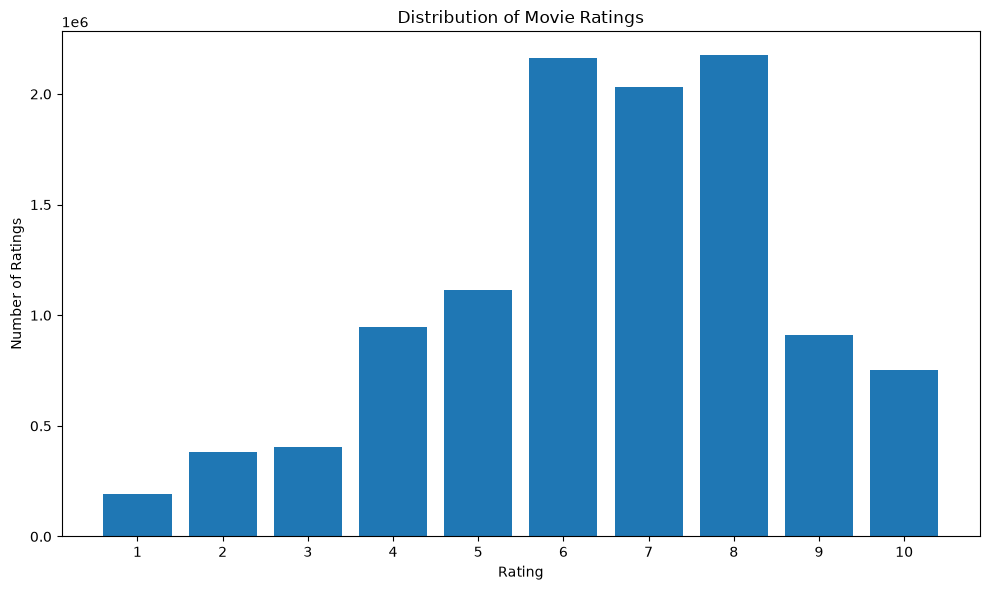

In [18]:
rating_counts = (
    ratings_df["rating_val"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 6))

plt.bar(
    rating_counts.index,
    rating_counts.values,
    width=0.8,
)

plt.xticks(range(1, 11))
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Movie Ratings")

plt.tight_layout()
plt.show()

### Consistency Between Ratings and Users

Before building the recommendation models, we verify the consistency between the **ratings** and **users** tables.

Every rating in `ratings_df` should correspond to a user present in `users_df`. We therefore compare the unique usernames found in both datasets and identify any users who appear in the ratings table but are missing from the users table.

This ensures that the user information is complete and that the two datasets can be reliably combined or linked when constructing the user–movie interaction matrix.

Users present in `users_df` but with no ratings are not considered an issue, as a user may be included in the dataset without having any recorded ratings.

In [22]:
rating_usernames = set(ratings_df["user_id"].dropna())
user_usernames = set(users_df["username"].dropna())

missing_users = rating_usernames - user_usernames

print(f"Unique users in ratings: {len(rating_usernames):,}")
print(f"Unique users in users: {len(user_usernames):,}")
print(f"Users in ratings but not in users: {len(missing_users):,}")

Unique users in ratings: 7,477
Unique users in users: 8,139
Users in ratings but not in users: 1


In [23]:
missing_users = rating_usernames - user_usernames

print(missing_users)

{'jacksonmaines'}


In [28]:
ratings_df[
    ratings_df["user_id"].isin(missing_users)
]["user_id"].value_counts()

user_id
jacksonmaines    1703
Name: count, dtype: int64

The ratings dataset contains 7,477 unique users, while the users dataset contains 8,139 users. When comparing both tables, only one username (`jacksonmaines`) appears in the ratings dataset but is not present in the users dataset.

Interestingly, this user has **1,703 recorded ratings**. Therefore, removing this user would result in a non-negligible loss of rating data. Since the ratings themselves contain all the information required for the collaborative filtering models, these ratings will be retained rather than discarded.

### Consistency Between Movies and Ratings

We now verify the consistency between the **movies** and **ratings** datasets.

Every `movie_id` appearing in `ratings_df` should correspond to a movie present in `movies_df`. We therefore compare the unique movie identifiers in both datasets and identify any movies that have ratings but are missing from the movie dataset.

This check is important because these ratings cannot be associated with movie metadata if the corresponding movie is not present in `movies_df`.

In [29]:
rating_movie_ids = set(ratings_df["movie_id"].dropna())
movie_ids = set(movies_df["movie_id"].dropna())

missing_movie_ids = rating_movie_ids - movie_ids

print(f"Unique movies in ratings: {len(rating_movie_ids):,}")
print(f"Unique movies in movies: {len(movie_ids):,}")
print(f"Movies in ratings but not in movies: {len(missing_movie_ids):,}")

Unique movies in ratings: 286,070
Unique movies in movies: 285,513
Movies in ratings but not in movies: 568


In [30]:
missing_movie_ratings = ratings_df[
    ratings_df["movie_id"].isin(missing_movie_ids)
]

print(
    f"Ratings associated with missing movies: "
    f"{len(missing_movie_ratings):,}"
)

Ratings associated with missing movies: 577


The consistency check identified ratings associated with movies that are not present in the movie dataset.

In total, **577 ratings** correspond to `movie_id` values that are missing from `movies_df`.

These ratings cannot currently be linked to the available movie metadata. Before proceeding with the processing pipeline, these records should therefore be examined and an appropriate strategy should be defined for handling them.